In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
#loading the dataset
df = pd.read_csv("/content/students.csv")

print(df.shape)
display(df.head())

(10000, 25)


,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,...,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
0,STU00000,15,M,B,phd,low,private,urban,2.0,91.7,...,yes,8.2,3.3,1.8,70.7,58.3,88.9,74.5,2.80,1
1,STU00001,23,F,A,phd,low,private,urban,14.2,76.8,...,yes,5.4,4.9,5.8,66.1,83.9,94.5,83.6,3.29,1
2,STU00002,22,F,B,bachelor,middle,public,suburban,3.3,83.1,...,yes,5.5,3.5,6.1,51.3,71.8,78.9,71.2,2.93,1
3,STU00003,19,M,D,some_college,high,public,suburban,17.9,72.8,...,yes,5.3,8.5,7.2,100.0,95.7,82.9,69.4,3.34,1
4,STU00004,19,M,C,some_college,middle,public,suburban,12.9,83.0,...,yes,7.5,1.0,4.5,87.5,73.0,88.5,74.8,3.27,1


The dataset contains 10,000 student records and 25 variables.

In [3]:
# Check missing values in each column
print(df.isnull().sum())

student_id                    0
age                           0
gender                        0
ethnicity                     0
parental_education            0
family_income                 0
school_type                   0
school_region                 0
study_hours_per_week          0
attendance_rate               0
extracurricular_activities    0
sports_participation          0
tutoring_sessions             0
parental_involvement          0
internet_access               0
has_laptop                    0
sleep_hours                   0
stress_level                  0
motivation_score              0
reading_score                 0
writing_score                 0
math_score                    0
science_score                 0
overall_gpa                   0
passed                        0
dtype: int64


The missing-value analysis shows that all columns contain zero missing values. Therefore, no missing-value treatment is required for this dataset at this stage.

In [4]:
# Check for duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Interpretation

The duplicate record analysis identified 0 duplicate rows in the dataset. This indicates that no completely identical records were found. Therefore, no duplicate records need to be removed during preprocessing.


In [5]:
# Check the data types of all columns
print(df.dtypes)

student_id                     object
age                             int64
gender                         object
ethnicity                      object
parental_education             object
family_income                  object
school_type                    object
school_region                  object
study_hours_per_week          float64
attendance_rate               float64
extracurricular_activities      int64
sports_participation           object
tutoring_sessions               int64
parental_involvement           object
internet_access                object
has_laptop                     object
sleep_hours                   float64
stress_level                  float64
motivation_score              float64
reading_score                 float64
writing_score                 float64
math_score                    float64
science_score                 float64
overall_gpa                   float64
passed                          int64
dtype: object


### Interpretation:

The dataset contains both numerical and categorical variables. Numerical variables include age, study hours, attendance rate, sleep hours, motivation score, academic scores, and overall GPA. Categorical variables include gender, ethnicity, parental education, family income, school type, and internet access. The `passed` column is an integer variable representing the target outcome. Categorical variables will require encoding before applying the machine learning model.


In [6]:
# Check the distribution of the target variable
print(df["passed"].value_counts())

passed
1    9610
0     390
Name: count, dtype: int64


### Interpretation:

The target variable contains two classes: 1 represents students who passed, and 0 represents students who failed. Out of 10,000 students, 9,610 passed and 390 failed. The distribution shows that the dataset is imbalanced because the number of passing students is considerably higher than the number of failing students.


In [7]:
# Statistical summary
df.describe()

,age,study_hours_per_week,attendance_rate,extracurricular_activities,tutoring_sessions,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.963000,11.157190,83.044980,2.520200,9.936400,6.990330,5.23876,5.524950,77.170010,76.963110,79.795860,78.965590,3.123890,0.961000
std,3.150369,5.915631,8.345282,1.708474,6.077948,1.191498,1.91925,2.011639,16.592537,16.348582,16.125256,16.092825,0.579559,0.193605
min,15.000000,0.000000,52.300000,0.000000,0.000000,4.000000,1.00000,1.000000,6.800000,5.000000,0.000000,15.500000,0.770000,0.000000
25%,17.000000,7.000000,77.300000,1.000000,5.000000,6.200000,3.90000,4.100000,65.600000,65.900000,68.600000,67.900000,2.730000,1.000000
50%,20.000000,11.100000,83.000000,3.000000,10.000000,7.000000,5.10000,5.500000,78.500000,78.000000,81.400000,80.300000,3.180000,1.000000
75%,23.000000,15.200000,88.900000,4.000000,15.000000,7.800000,6.40000,6.900000,90.700000,90.100000,94.000000,92.500000,3.580000,1.000000
max,25.000000,35.700000,100.000000,5.000000,20.000000,10.000000,10.00000,10.000000,100.000000,100.000000,100.000000,100.000000,4.000000,1.000000


### Interpretation:

The statistical summary provides information about the numerical variables in the dataset, including their count, mean, standard deviation, minimum, quartiles, and maximum values. The dataset contains 10,000 records. The average attendance rate is approximately 83.04%, while the average study time is approximately 11.16 hours per week. The average overall GPA is 3.12. The `passed` column has a mean of 0.961, indicating that most students in the dataset passed.


In [8]:
# Unique values in categorical columns
print(df.select_dtypes(include="object").nunique())

student_id              10000
gender                      3
ethnicity                   5
parental_education          6
family_income               3
school_type                 3
school_region               3
sports_participation        2
parental_involvement        3
internet_access             2
has_laptop                  2
dtype: int64


### Interpretation:

The categorical variables contain different numbers of unique values. The `gender` column has 3 unique categories, while `ethnicity` has 5 and `parental_education` has 6. The remaining categorical variables contain between 2 and 3 categories, except `student_id`, which has 10,000 unique values. Since `student_id` is an identifier and does not provide meaningful information for prediction, it will be excluded from model training. The other categorical variables will be encoded before building the machine learning model.


In [9]:
# Remove the identifier column
df = df.drop("student_id", axis=1)

print(df.shape)

(10000, 24)


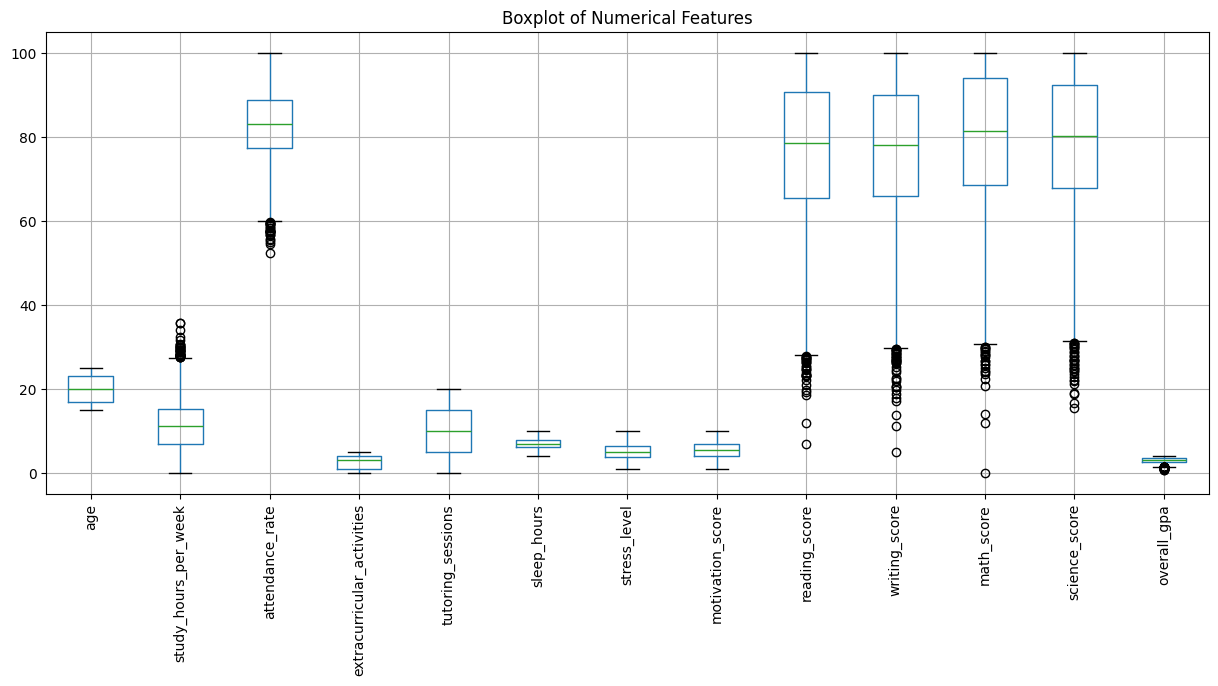

In [10]:
# Boxplot of numerical features
df.select_dtypes(include="number").drop("passed", axis=1).boxplot(figsize=(15, 6))

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

### Interpretation:

The boxplot was used to identify potential outliers in the numerical variables. Some values appear outside the whiskers in features such as study hours, attendance rate, and academic scores. These values may represent unusual student records, so they will not be removed automatically. The data will be retained unless further investigation shows that the values are invalid or errors.


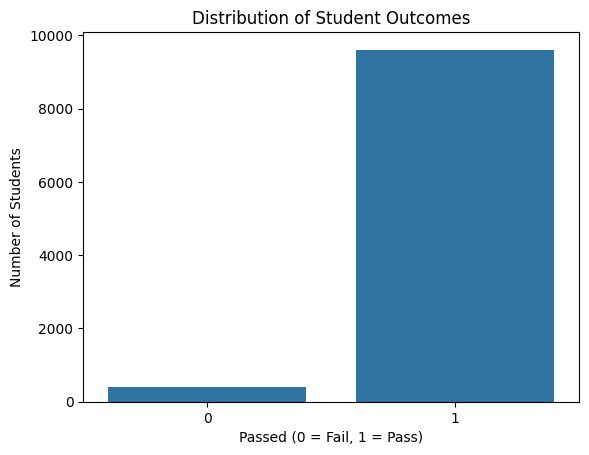

In [11]:
# Pass/Fail distribution
sns.countplot(x="passed", data=df)

plt.title("Distribution of Student Outcomes")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")
plt.show()

### Interpretation:

The bar chart shows the distribution of student outcomes. The number of students who passed (1) is considerably higher than the number of students who failed (0). This indicates that the target variable is imbalanced, which we will should be considering while evaluating the machine learning model.


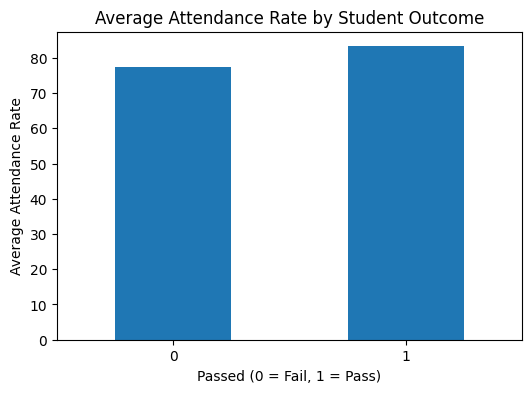

In [12]:
# Average attendance by outcome
df.groupby("passed")["attendance_rate"].mean().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Attendance Rate by Student Outcome")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Average Attendance Rate")
plt.xticks(rotation=0)
plt.show()

### Interpretation:

The bar chart compares the average attendance rates of students based on their outcomes. Students who passed had a higher average attendance rate than students who failed. This suggests that attendance may be associated with student outcomes in this dataset.


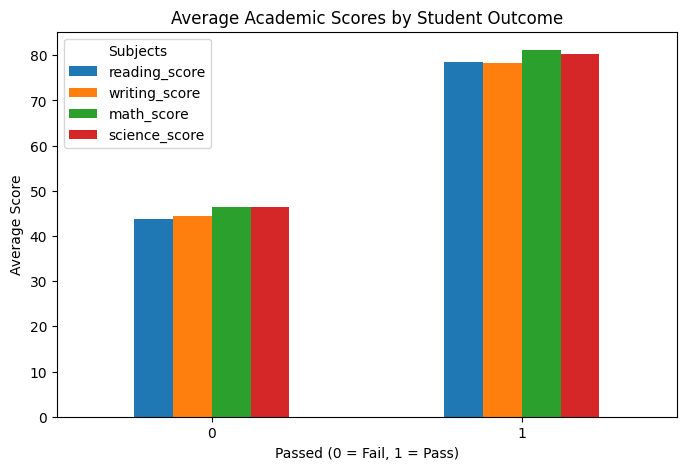

In [13]:
# Average academic scores by outcome
df.groupby("passed")[[
    "reading_score",
    "writing_score",
    "math_score",
    "science_score"
]].mean().plot(kind="bar", figsize=(8, 5))

plt.title("Average Academic Scores by Student Outcome")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.show()

### Interpretation:

The bar chart compares the average reading, writing, mathematics, and science scores of students based on their final outcome. Students who passed have higher average scores in all four subjects than students who failed. The passing group has an average mathematics score of approximately 81, while the failing group has an average mathematics score of approximately 46. Similar differences can be observed in reading, writing, and science scores. This indicates that academic performance is associated with the student outcome in this dataset. However, these results describe relationships in the dataset and do not independently prove that higher scores cause students to pass.


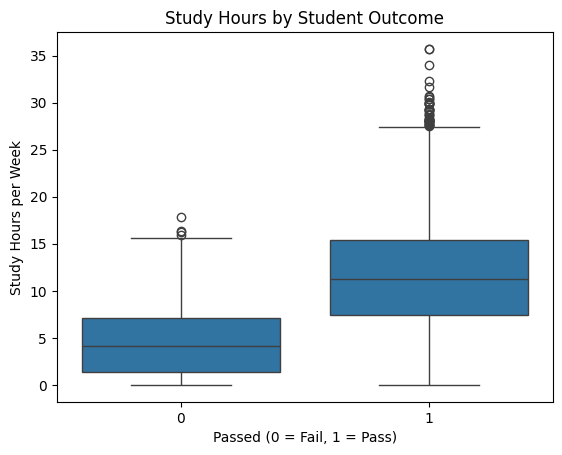

In [14]:
# Study hours by student outcome
sns.boxplot(x="passed", y="study_hours_per_week", data=df)

plt.title("Study Hours by Student Outcome")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Study Hours per Week")
plt.show()

### Interpretation:

The boxplot compares the study hours per week of students based on their passing status. It helps to understand the distribution of study hours among students who passed and those who failed. The graph shows differences in the study-hour patterns between the two groups. This suggests that study habits may have a relationship with student outcomes. However, the graph alone cannot establish that study hours directly cause students to pass or fail.


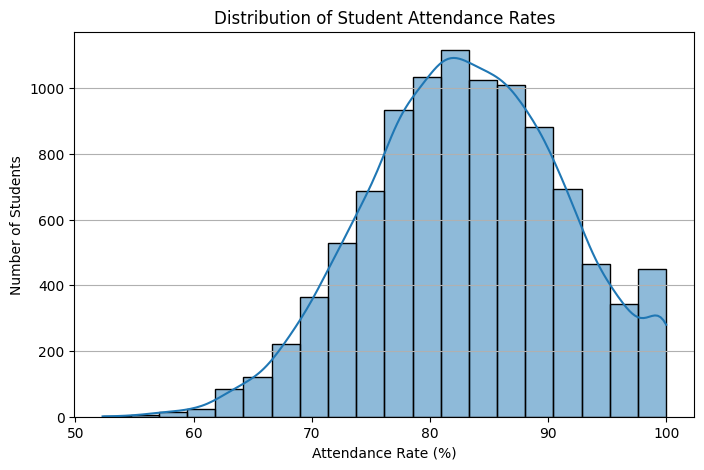

In [15]:
# Distribution of student attendance rates

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="attendance_rate",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Attendance Rates")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Number of Students")
plt.grid(axis="y")
plt.show()

### Interpretation

The attendance distribution shows that most students have attendance rates between approximately 75% and 95%. The distribution is concentrated around 80%–90%, while fewer students have very low attendance rates. This helps us understand the overall attendance pattern in the dataset.

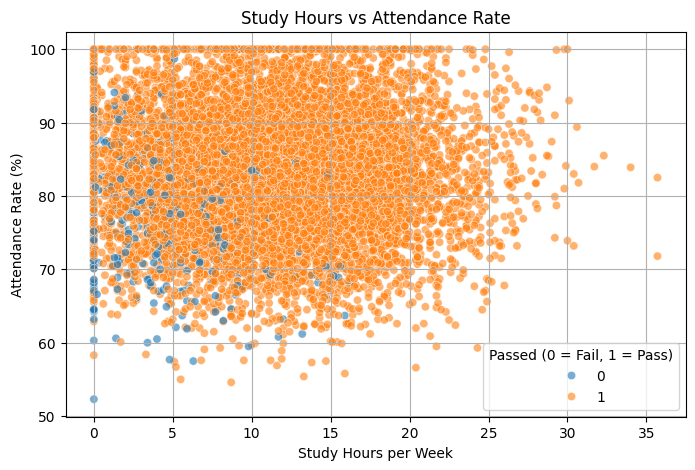

In [16]:
# Relationship between study hours and attendance

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours_per_week",
    y="attendance_rate",
    hue="passed",
    alpha=0.6
)

plt.title("Study Hours vs Attendance Rate")
plt.xlabel("Study Hours per Week")
plt.ylabel("Attendance Rate (%)")
plt.legend(title="Passed (0 = Fail, 1 = Pass)")
plt.grid()
plt.show()

### Interpretation

The scatter plot shows the relationship between weekly study hours and attendance rate, with points colored according to the passing outcome. Students who passed are distributed across different study hours and attendance levels. The graph does not show a clear strong relationship between study hours and attendance, indicating that other factors may also influence student outcomes.

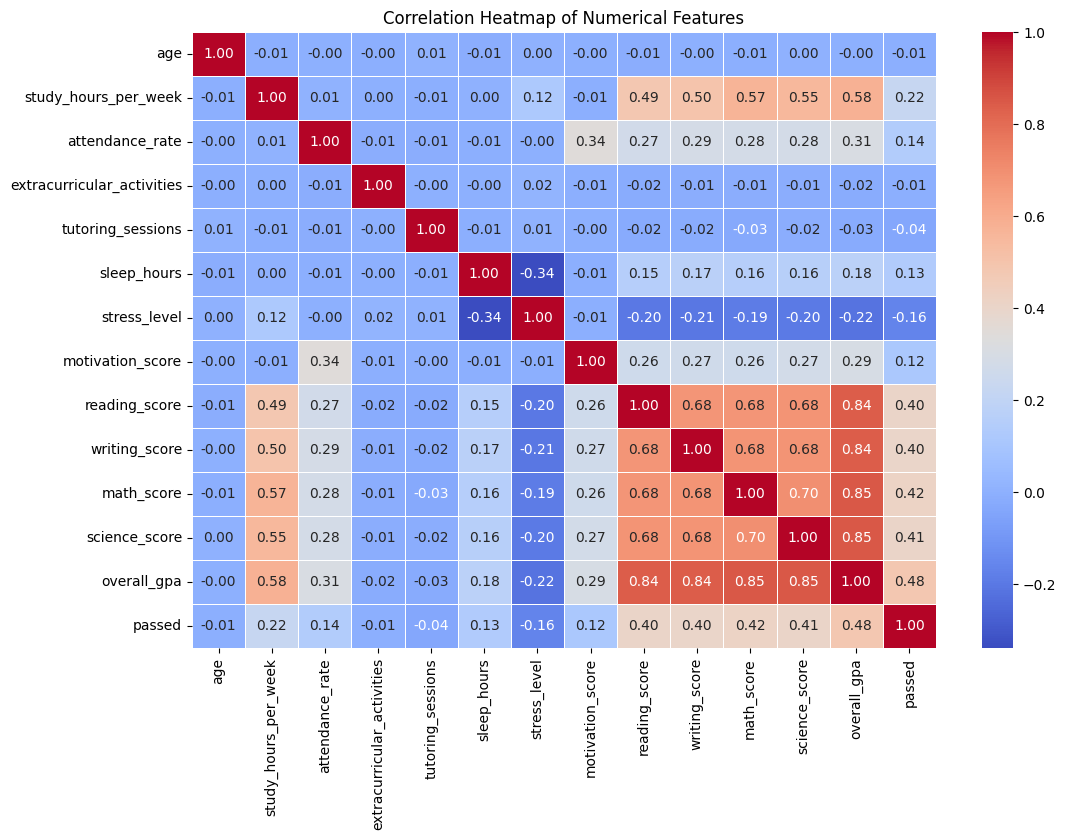

In [17]:
# Correlation heatmap of numerical features

plt.figure(figsize=(12, 8))

numeric_data = df.select_dtypes(include="number")

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Interpretation

The correlation heatmap shows the relationships between numerical features in the dataset. Overall GPA has the strongest positive correlation with the passed target (0.48), followed by math score (0.42), science score (0.41), and reading and writing scores (0.40). Study hours have a weaker positive correlation with passing (0.22), while stress level has a weak negative correlation (-0.16).

Overall GPA and subject scores were excluded from the model features to reduce potential target leakage. Correlation shows relationships between variables but does not prove causation.

In [18]:
# Select input features
X = df.drop([
    "passed",
    "overall_gpa",
    "reading_score",
    "writing_score",
    "math_score",
    "science_score"
], axis=1)

y = df["passed"]

print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (10000, 18)
Target: (10000,)


### Interpretation:

The input features and target variable were separated for supervised learning. The `passed` column was selected as the target variable, while the remaining relevant student attributes were selected as input features. Overall GPA and subject scores were excluded to reduce the possibility of target leakage. The dataset is now prepared for further preprocessing and model training.


In [19]:
# Separate numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'study_hours_per_week', 'attendance_rate', 'extracurricular_activities', 'tutoring_sessions', 'sleep_hours', 'stress_level', 'motivation_score']

Categorical features:
['gender', 'ethnicity', 'parental_education', 'family_income', 'school_type', 'school_region', 'sports_participation', 'parental_involvement', 'internet_access', 'has_laptop']


### Interpretation:

The input features were divided into numerical and categorical variables. The dataset contains 8 numerical features and 10 categorical features. Numerical features will be standardized, while categorical features will be converted into numerical form using one-hot encoding. This preprocessing will make the data suitable for training the Logistic Regression model.


In [20]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 18)
Testing data: (2000, 18)


### Interpretation:

The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data. Stratified splitting was applied to preserve the distribution of the target classes in both sets. The random state ensures reproducible results.


In [21]:
#Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
# Build and train Logistic Regression with balanced class weights
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


The Logistic Regression model was trained using balanced class weights to give additional importance to the minority class (failed students). This helps the model identify failed students in the imbalanced dataset.

In [23]:
# Predict student outcomes using the trained model
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Total predictions:", len(y_pred))
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Total predictions:", len(y_pred))

Predictions generated successfully.
Total predictions: 2000
Predictions generated successfully.
Total predictions: 2000


The trained Logistic Regression model generated predictions for all 2,000 students in the testing dataset. These predictions were used to evaluate the model's performance on unseen data.

In [24]:
# Calculate performance metrics for the balanced model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Model Evaluation Results
------------------------
Accuracy: 0.86
Precision: 0.9946
Recall: 0.859
F1 Score: 0.9218

Classification Report:
              precision    recall  f1-score   support

        Fail       0.20      0.88      0.33        78
        Pass       0.99      0.86      0.92      1922

    accuracy                           0.86      2000
   macro avg       0.60      0.87      0.63      2000
weighted avg       0.96      0.86      0.90      2000



**Interpretation**:

The initial Logistic Regression model with balanced class weights achieved an accuracy of 86%. Although the model identified 88% of the actual failed students, its precision for the Fail class was low. This indicated that several passing students were incorrectly classified as failed. Therefore, another model was tested to improve the overall accuracy.

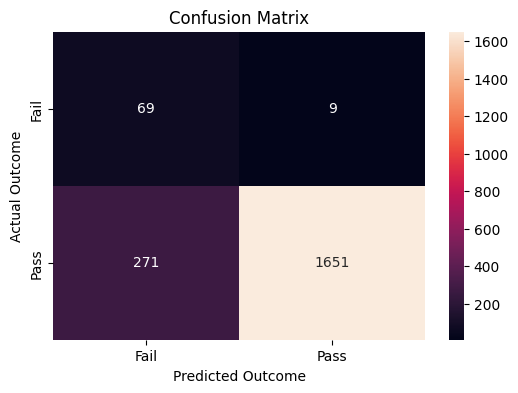

In [25]:
# Visualize correct and incorrect predictions for both classes
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.title("Confusion Matrix")
plt.show()

**Interpretation**:

The confusion matrix shows that the balanced model correctly predicted 69 failed students and 1,651 passing students. It incorrectly classified 9 failed students as passed and 271 passing students as failed. The model detected most failed students, but it also produced a relatively high number of false-positive failure predictions.

In [26]:
# Training a second model without class weighting for comparison
model_unbalanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
model_unbalanced.fit(X_train, y_train)

# Generate predictions
y_pred_unbalanced = model_unbalanced.predict(X_test)

# Calculate accuracy
accuracy_unbalanced = accuracy_score(y_test, y_pred_unbalanced)

print("Accuracy without class weighting:",
      round(accuracy_unbalanced, 4))

Accuracy without class weighting: 0.965


**Interpretation:**

A second Logistic Regression model was trained without class weighting to compare its performance with the balanced model. The model achieved an accuracy of 96.5%, improving the accuracy from 86% to 96.5%. However, additional evaluation was required to check whether the improvement affected the detection of failed students.

In [27]:
# Evaluate the model without class weighting
print("Classification Report (Without Class Weighting)")
print(classification_report(
    y_test,
    y_pred_unbalanced,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Classification Report (Without Class Weighting)
              precision    recall  f1-score   support

        Fail       0.70      0.18      0.29        78
        Pass       0.97      1.00      0.98      1922

    accuracy                           0.96      2000
   macro avg       0.83      0.59      0.63      2000
weighted avg       0.96      0.96      0.95      2000



**Interpretation:**

The Logistic Regression model without class weighting achieved an accuracy of approximately 96.5%. The model performed strongly for the Pass class, with a recall of approximately 1.00. However, the recall for the Fail class was only 0.18, meaning that it correctly identified 14 out of 78 failed students. This shows that the improved accuracy came with reduced detection of the minority class.

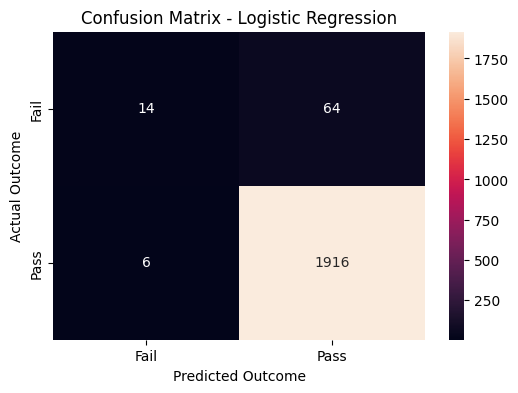

In [28]:
# Confusion matrix for the unbalanced model
cm_unbalanced = confusion_matrix(y_test, y_pred_unbalanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_unbalanced,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Interpretation:**

The confusion matrix shows that the model correctly predicted 1,916 passing students and 14 failed students. However, 64 failed students were incorrectly classified as passed. Only 14 out of 78 actual failed students were detected. Although the model achieved 96.5% accuracy, the confusion matrix highlights the limitation of relying on accuracy alone when the dataset is imbalanced.

In [29]:
# Compare the performance of both Logistic Regression models
comparison = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Logistic Regression Without Class Weighting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_unbalanced)
    ],
    "Fail Recall": [
        recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        recall_score(y_test, y_pred_unbalanced, pos_label=0, zero_division=0)
    ],
    "Fail F1 Score": [
        f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        f1_score(y_test, y_pred_unbalanced, pos_label=0, zero_division=0)
    ]
})

display(comparison.round(4))

,Model,Accuracy,Fail Recall,Fail F1 Score
0,Balanced Logistic Regression,0.860,0.8846,0.3301
1,Logistic Regression Without Class Weighting,0.965,0.1795,0.2857


**Interpretation:**

Two Logistic Regression models were compared to evaluate the effect of class weighting on student outcome prediction. The model with balanced class weights achieved an accuracy of 86%, a Fail recall of 88.46%, and a Fail F1-score of 33.01%. The Logistic Regression model without class weighting achieved a higher accuracy of 96.5%. However, its Fail recall decreased to 17.95%, and its Fail F1-score was 28.57%. This indicates that the model without class weighting improved overall accuracy but was less effective at identifying students who actually failed. Therefore, accuracy alone is not sufficient to evaluate the model because the dataset contains an imbalance between the Pass and Fail classes.

In [30]:
# Final evaluation of the selected Balanced Logistic Regression model

from sklearn.metrics import accuracy_score, classification_report

# Generate final predictions
y_pred_final = model.predict(X_test)

# Calculate accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model: Balanced Logistic Regression")
print("-----------------------------------------")
print("Accuracy:", round(final_accuracy, 4))

# Display classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Fail", "Pass"]
))

Final Model: Balanced Logistic Regression
-----------------------------------------
Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

        Fail       0.20      0.88      0.33        78
        Pass       0.99      0.86      0.92      1922

    accuracy                           0.86      2000
   macro avg       0.60      0.87      0.63      2000
weighted avg       0.96      0.86      0.90      2000



### Interpretation of Final Model Evaluation ###

The selected Balanced Logistic Regression model achieved an overall accuracy of **86%**. The model obtained a recall of **88% for the Fail class**, meaning it correctly identified most of the students who actually failed.

However, the precision for the Fail class was **20%**, which means that some students predicted as failing actually passed. The Pass class achieved a precision of 99% and a recall of 86%.

Since the dataset contains significantly more passing students than failing students, accuracy alone is not sufficient to evaluate the model. Fail recall is an important metric because identifying students who may fail is the main objective of this project.

Therefore, Balanced Logistic Regression was selected as the primary model because it provides substantially higher Fail recall than the other tested models. The results also show that the model has limitations and may generate false predictions, so its predictions should be used as an early warning rather than a final decision about student performance.


## Conclusion

This project used machine learning to predict student pass and fail outcomes using academic, attendance, and demographic-related features. The dataset was preprocessed, analyzed through exploratory data analysis, and used to train Logistic Regression models.

Three different class-weight configurations were compared. Balanced Logistic Regression was selected as the primary model because it achieved a Fail recall of approximately 88.46%, helping identify a larger proportion of students who actually failed.

The project demonstrates how machine learning can support the early identification of students who may require additional academic assistance. However, the model's predictions should be considered supportive information rather than a final judgment of student performance.


## Limitations

1. **Imbalanced Dataset:** The dataset contains significantly more passing students than failing students, which affects model performance.
2. **False Predictions:** The selected model produces false positives and false negatives.
3. **Limited Features:** The model uses only the available dataset features and may not include other factors that influence student performance.
4. **Model Generalization:** The model was evaluated on one dataset and may not perform similarly on students from other institutions or populations.
5. **Prediction Reliability:** The model should be used as an early-warning support tool and not as the sole basis for making decisions about students.


## Test a student from the dataset ##

In [31]:
# Select one student from the test dataset
sample_student = X_test.iloc[[0]]

# Get the actual outcome
actual_outcome = y_test.iloc[0]

# Predict the student's outcome
predicted_outcome = model.predict(sample_student)[0]

# Convert numerical prediction into a readable label
actual_label = "Pass" if actual_outcome == 1 else "Fail"
predicted_label = "Pass" if predicted_outcome == 1 else "Fail"

print("Actual Outcome:", actual_label)
print("Predicted Outcome:", predicted_label)

Actual Outcome: Pass
Predicted Outcome: Pass


In [32]:
# Display the selected student's feature values
display(sample_student)

,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,extracurricular_activities,sports_participation,tutoring_sessions,parental_involvement,internet_access,has_laptop,sleep_hours,stress_level,motivation_score
5123,22,M,D,bachelor,middle,charter,urban,18.0,88.4,5,no,5,medium,yes,yes,6.9,3.1,3.8


In [33]:
# Create a hypothetical student with lower academic indicators

fail_student = pd.DataFrame([{
    "age": 18,
    "gender": "M",
    "ethnicity": "D",
    "parental_education": "highschool",
    "family_income": "low",
    "school_type": "public",
    "school_region": "urban",
    "study_hours_per_week": 2.0,
    "attendance_rate": 55.0,
    "extracurricular_activities": 0,
    "sports_participation": "no",
    "tutoring_sessions": 0,
    "parental_involvement": "low",
    "internet_access": "yes",
    "has_laptop": "no",
    "sleep_hours": 5.0,
    "stress_level": 9.0,
    "motivation_score": 2.0
}])

# Predict the outcome
fail_prediction = model.predict(fail_student)[0]

# Convert prediction to a readable label
fail_label = "Pass" if fail_prediction == 1 else "Fail"

print("Predicted Outcome:", fail_label)

Predicted Outcome: Fail


### Interpretation: ###

**Pass Student:** The model predicted Pass, demonstrating how the trained model can estimate an individual student's outcome.

**Fail Student:** The model predicted Fail, showing how it can help identify students who may be at risk of failing.